{'topic': '莲花', 'poem': '《咏莲》\n碧水浮香远，亭亭立素姿。\n不争春色艳，独抱月明时。\n影落清波浅，心同玉露滋。\n何须风送语，一念一菩提。\n\n赏析：这首作品以莲花为吟咏对象，通过“碧水”、“素姿”、“清波”等意象，勾勒出莲花清雅高洁的形态。诗中“不争春色艳，独抱月明时”一句，既展现了莲花不与百花争春的淡泊，又凸显其独守高洁的品格。尾联“何须风送语，一念一菩提”则升华主题，将莲花与禅意相结合，传达出超然物外的境界。', 'ci_poem': '《临江仙·莲》\n水佩风裳香满浦，红衣半落斜阳。\n蜻蜓点破碧云光。鹭窥荷背立，鱼戏叶间藏。\n莫问秋心何处寄，月明常伴清霜。\n濂溪千载有遗章。不枝真品格，无蔓自幽芳。\n\n注：我的仿作以周邦彦《苏幕遮》的清丽笔触为基调，融入周敦颐《爱莲说》中“不蔓不枝”的君子意象。上片通过蜻蜓、鹭鸶、游鱼等动态生灵，烘托莲塘的静谧禅意；下片“濂溪遗章”暗指理学宗师对莲的礼赞，末句“不枝真品格”既是对莲茎特质的白描，更是对君子之风的人格隐喻。', 'joke': '关于“莲花”的笑话，我为你准备了一个小段子，希望能博你一笑：\n\n**《莲花与淤泥》**\n\n一朵莲花对旁边的淤泥嫌弃地说：“你看我多干净、多清香，再看看你，又脏又臭，真是配不上我！”\n\n淤泥慢悠悠地叹了口气：“哎，你倒是光鲜亮丽，可别忘了——要是没我在这儿‘衬托’，大家怎么知道你‘出淤泥而不染’呢？你这是典型的‘蹭完热度还嫌平台low’啊！”\n\n莲花无语，心想：这届泥巴，嘴也太毒了。'}


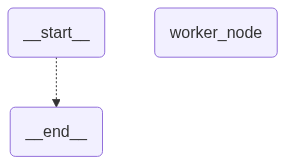

In [10]:
# -*- coding: utf-8 -*-
# 【CP2-06 动态分支 Send】Send 动态生成 N 个并行子任务（Map）
# 文件：CP2/06_dynamic_branch.ipynb
# 作用：本 Cell 演示 【CP2-06 动态分支 Send】Send 动态生成 N 个并行子任务（Map） 的完整可运行示例
# 阅读顺序：状态定义 → 节点定义 → 图构建 → 编译执行 → 结果观察

from dotenv import load_dotenv
from typing import TypedDict
from langchain_deepseek import ChatDeepSeek
from langgraph.graph import StateGraph,START,END    
from langchain.messages import HumanMessage
from langgraph.types import Send
from typing import TypedDict, Annotated,Literal,Sequence

load_dotenv()
CONTENT_TYPES = ["poem","ci_poem","joke"]
model = ChatDeepSeek(
    model = "deepseek-v4-flash",
    extra_body = {
        "thinking":{
            "type" : "disabled"
        }
    }
)

class OverAllState(TypedDict):
    topic: str
    poem : str
    ci_poem : str
    joke : str

# 私有状态
class WorkerState(TypedDict):
    content_type : Literal ["poem","ci_poem","joke"]
    prompt : str

# 输入状态
class InputState(TypedDict):
    topic : str

# 输出状态
class OutputState(TypedDict):
    poem : str
    ci_poem : str
    joke : str

# 定义节点
def worker_node(state: WorkerState) -> OutputState:
    content_type = state["content_type"]
    prompt = state["prompt"]
    response = model.invoke(prompt).content
    return {content_type: response}

# 动态分支路由
def router(state: InputState) -> Sequence[Send]:
    router_prompt = "请生成关于 {} 的 {}"
    english2chinese = {
        "poem" : "诗",
        "ci_poem" : "词",
        "joke" : "笑话"
    }
    topic = state["topic"]
    return [
        Send (
            "worker_node",
            {
                "content_type": content_type,
                "prompt": router_prompt.format(topic,english2chinese[content_type])
            }
        ) for content_type in CONTENT_TYPES
    ]

# 构建图
builder = StateGraph(state_schema= OverAllState, input_state_schema= InputState, output_state_schema= OutputState)  # 创建状态图构建器：绑定状态 Schema
builder.add_node("worker_node",worker_node)  # 注册节点到图中
builder.add_conditional_edges(  # 条件边 + path_map：路由键与节点名解耦
    START,
    router,
    path_map={"worker_node"},
)
builder.add_edge("worker_node",END)  # 汇入终点

graph = builder.compile()  # 编译图：蓝图→可执行对象

res=graph.invoke({"topic":"莲花"})  # 触发图执行：传入初始 State + config
print(res)

from IPython.display import display
display(graph)
